In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import plot_tree

In [ ]:
import seaborn as sns

# Load dataset
df = sns.load_dataset("iris")

print(df.head())
print(df.shape)
print(df.columns)


   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
(150, 5)
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')


In [ ]:
X = df.drop("species", axis=1)
y = df["species"]

print("Features:")
print(X.columns)

print("\nTarget classes:")
print(y.unique())

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width'], dtype='object')

Target classes:
['setosa' 'versicolor' 'virginica']

X shape: (150, 4)
y shape: (150,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

In [ ]:
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print(y_pred)

['setosa' 'virginica' 'versicolor' 'versicolor' 'setosa' 'versicolor'
 'setosa' 'setosa' 'virginica' 'versicolor' 'virginica' 'virginica'
 'virginica' 'versicolor' 'setosa' 'setosa' 'setosa' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'virginica' 'versicolor' 'virginica'
 'virginica' 'virginica' 'versicolor' 'setosa' 'virginica' 'setosa']


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100, "%")

Accuracy: 0.9666666666666667
Accuracy percentage: 96.66666666666667 %


In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



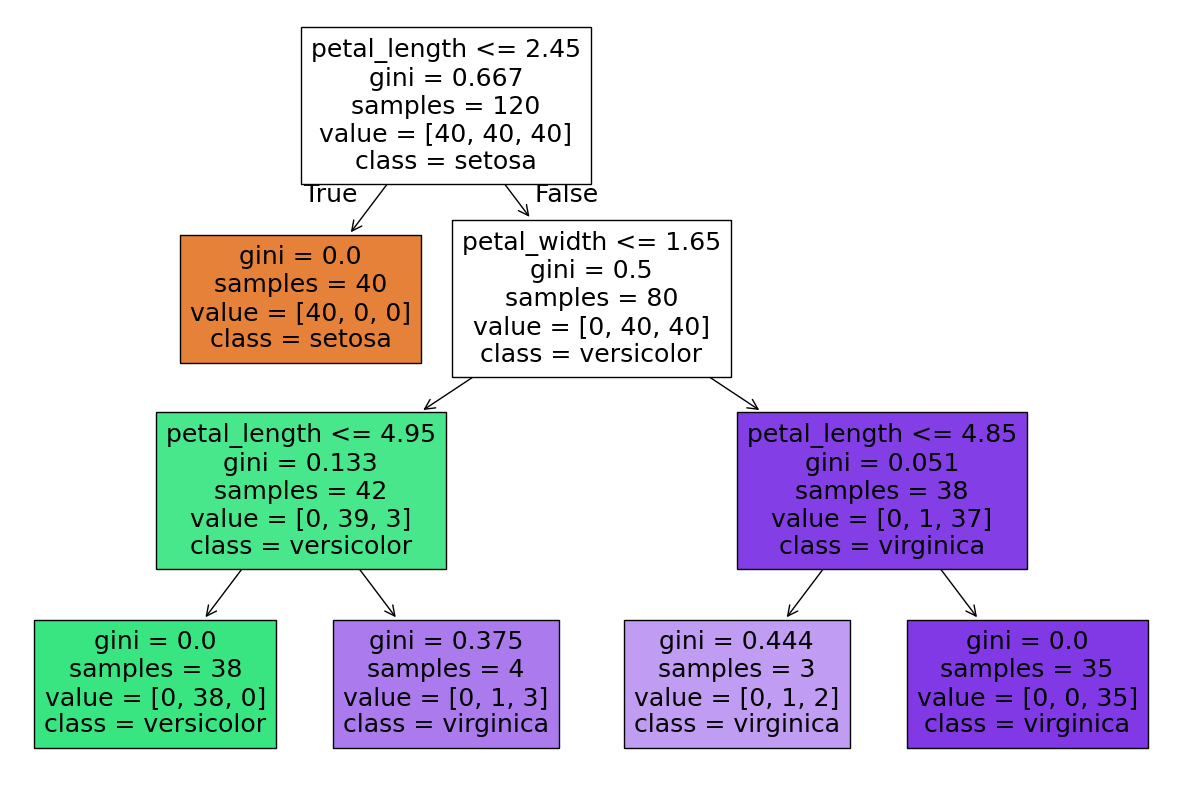

In [ ]:
plt.figure(figsize=(15, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True
)

plt.show()